# Spontaneous emission of TLS: TCP socket

Here, we introduce the two-level system (TLS) spontaneous emission tutorial using `maxwelllink.Molecule` and a TCP socket.

## 1. Setting up the socket communication layer

Using the TCP socket requires setting the `hostname` and `port number`. On a local machine, we can use the helper function `get_available_host_port()` from **MaxwellLink** to obtain these two pieces of information. Then, we initialize a `SocketHub` instance to provide the socket communication in **MaxwellLink**.

In [1]:
import numpy as np
import maxwelllink as mxl
from maxwelllink import sockets as mxs

try:
    import meep as mp
except ImportError as exc:  
    raise RuntimeError(
        "Meep is required for this tutorial."
        "Install via conda: conda install -c conda-forge pymeep=*=mpi_mpich_*"
    ) from exc

host, port = mxs.get_available_host_port()
hub = mxl.SocketHub(host=host, port=port, timeout=10.0, latency=1e-5)

print(f"SocketHub listening on {host}:{port}")


Using MPI version 4.1, 1 processes
SocketHub listening on 127.0.0.1:51995


Before the simulation, users can understand the units system in MEEP with the following built-in function:

In [2]:
# or use: mxl.meep_units_helper(length_units_nm=2.9979E+01)
mxl.meep_units_helper(time_units_fs=0.1)

Now let's take a moment to understand the Meep unit system based on your provided units:
Given that you have specified:
- Time unit: 0.1 fs
By further assuming the MEEP simulation resolution is 10 pixels per length unit, we can derive the following Meep units:


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1

## 2. Bind Molecule and EM solver to the SocketHub

Then, we create a `Molecule` instance to define the information of this molecule in the EM simulation environment, including the `center`, `size`, `sigma` (width of the molecular polarization distribution), and `dimensions`. 

We also need to setup the EM solver (**MEEP**) using `mxl.MeepSimulation`. This class is a wrapper of the `meep.Simulation` object with extended parameters for **MaxwellLink**.

In [3]:
molecule = mxl.Molecule(
    hub=hub,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(1, 1, 1),
    sigma=0.1,
    dimensions=2,
)

sim = mxl.MeepSimulation(
    hub=hub,
    molecules=[molecule],
    cell_size=mp.Vector3(8, 8, 0),
    boundary_layers=[mp.PML(3.0)],
    resolution=10,
    # fix a units system 
    time_units_fs=0.1,
)


[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 1.0000E-01 fs = 4.1341E+00 a.u.
 - Length [x]: 1 mu = 2.9979E+01 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 4.1375E+01 eV = 3.3371E+05 cm-1 = 1.5205E+00 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 2.4169E-02 mu
 - Electric field [E]: 1 mu = 6.6486E+07 V/m = 1.2930E-04 a.u.

 Given the simulation resolution = 10,
 - FDTD dt = 5.0000E-02 mu (0.5/r

## 3. Python way to launch `mxl_driver` on a separate terminal

Generally, using the Socket Interface requires launching the EM simulation in one terminal and then starting the molecular driver simulation in a separate terminal. To avoid opening a second terminal, below we introduce a Python helper function `launch_tls_driver(...)`, which will launch `mxl_driver` from Python (so we can stay within this notebook to finish this tutorial).

Here, we set the TLS starting at the initial excited-state population of 1e-4.

Immediately after launching this driver in the background, we run the simulation using `sim.run(...)`. This function is a wrapper of the `meep.Simulation.run(...)` function, which can accept user-defined step functions.

In [4]:
import shlex
import shutil
import subprocess
import time


def launch_tls_driver(host: str, port: int, sleep_time: float = 0.5):
    executable = shutil.which('mxl_driver')
    if executable is None:
        raise RuntimeError('mxl_driver executable not found in PATH.')
    cmd = (
        f"{executable} --model tls --address {host} --port {port}"
        f' --param "omega=0.242, mu12=187, orientation=2, pe_initial=1e-4"'
    )
    print('Launching TLS driver via subprocess...')
    print('If you prefer to run it manually, execute:')
    print('  ' + cmd)
    argv = shlex.split(cmd)
    proc = subprocess.Popen(argv)
    time.sleep(sleep_time)
    return proc

launch_tls_driver(host, port)

sim.run(until=400)

Launching TLS driver via subprocess...
If you prefer to run it manually, execute:
  /Users/taoli/miniforge3/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 51995 --param "omega=0.242, mu12=187, orientation=2, pe_initial=1e-4"
-----------
Initializing structure...
time for choose_chunkdivision = 0.000104 s
Working in 2D dimensions.
Computational cell is 8 x 8 x 0 with resolution 10
time for set_epsilon = 0.002619 s
-----------
[initialization] Time step in atomic units:[SocketHub] CONNECTED: mol 0 <- 127.0.0.1:51996
 0.20670686667500004
[initialization] Assigned a molecular ID: 0
init TLSModel with dt = 0.206707 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
run 0 finished at t = 400.0 (8000 timesteps)
[SocketHub] DISCONNECTED: mol 0 from 127.0.0.1:51996
Received STOP, exiting


## 4. Retrieve molecular simulation data

After the simulation, we can retrieve molecular simulation data from `molecule.extra`, a Python dictionary which stores the molecular information sent from the driver code at each step of the simulation.

In [5]:
# users can also use molecule.additional_data_history to access the time-resolved data recorded during the simulation, 
# population = np.array([entry["Pe"] for entry in molecule.additional_data_history])
# time_au = np.array([entry["time_au"] for entry in molecule.additional_data_history])
# but here we demonstrate the use of molecule.extra which is more convenient for post-processing and plotting. 

population = molecule.extra["Pe"]
time_au = molecule.extra["time_au"]

print(f"Collected {population.size} samples.")

Collected 8001 samples.


## 5. Compare with the Analytical Golden-Rule Decay

Finally, we can compare this numerical simulation with analytical golden-rule rate calculations, with the 2D  spontaneus emission in vacuum as:

$$
k_{\rm {FGR}} = \frac{|\mu_{12}|^2 \omega^2}{2\hbar\epsilon_0 c^2}
$$

The corresponding TLS excited-state population decay dynamics obey:

$$
P_{\rm e}^{\rm {QM}}(t) = P_{\rm e}(0) e^{-k_{\rm{FGR}} t}
$$

When the EM field is described entirely classically, more than half a century ago, Jaynes and collaborators (https://ieeexplore.ieee.org/document/1443594) calculated the semiclassical spontaneous emission rate. More recently, we have also reproduced this semiclassical excited-state population decay (https://doi.org/10.1103/PhysRevA.97.032105):

$$
P_{\rm e}^{\rm {sc}}(t) = \frac{e^{-k_{\rm{FGR}} t}}{e^{-k_{\rm{FGR}} t} + \frac{1 - P_{\rm e}(0) }{P_{\rm e}(0) }}
$$

When $P_{\rm e}(0)\rightarrow 0$, the semiclassical decay dynamics exactly agree with the quantum correspondance $P_{\rm e}^{\rm {QM}}(t)$.

As shown below, using $P_{\rm e}(0)= 10^{-4}$, our semiclassical simulation exactly reproduces the quantum golden-rule decay.

std_dev=2.012e-03, max_abs_diff=7.928e-03


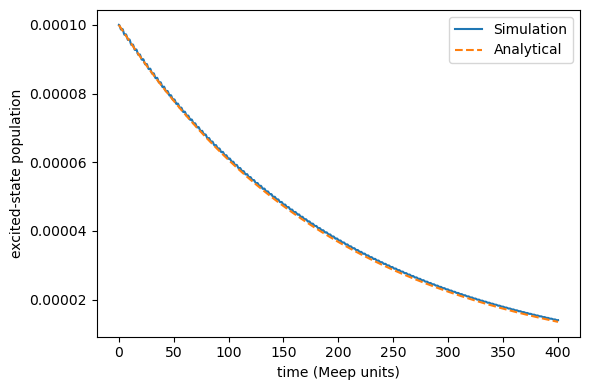

In [6]:
time_fs = time_au * 0.02418884254
time_meep = time_fs / 0.1
initial = population[0]
dipole_moment = 0.1 # meep units of mu12
frequency = 1.0 # meep units of omega

# analytical golden-rule decay rate
gamma = dipole_moment**2 * frequency**2 / 2.0

# simple exponential decay reference
reference = initial * np.exp(-time_meep * gamma)

# below is a more accurate reference which works under any initial population
#reference = np.exp(-time_meep * gamma) / (
#    np.exp(-time_meep * gamma) + (1.0 - initial) / initial
#)

std_rel = np.std(population - reference) / initial
max_rel = np.max(np.abs(population - reference)) / initial
print(f"std_dev={std_rel:.3e}, max_abs_diff={max_rel:.3e}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(time_meep, population, label="Simulation")
plt.plot(time_meep, reference, label="Analytical", linestyle="--")
plt.xlabel("time (Meep units)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Spontaneous emission in 3D vacuum

We next extend the above calculation to 3D vacuum. Here, we will use `polarization_type="transverse"` for the molecular polarization distribution, so that the spontaneous emission decay becomes smooth in 3D.

In [7]:
from maxwelllink.units import AU_TO_FS, wavelength_nm_from_omega

omega_au_3d = 0.484
mu12_au_3d = 187.0
pe_initial_3d = 0.1
c_au = 137.03599

length_units_nm_3d = 1000.0
interior_size_nm_3d = 100.0
resolution_3d = 110.0
steps_3d = 850

wavelength_nm_3d = wavelength_nm_from_omega(omega_au_3d, units="au")
pml_thickness_3d = wavelength_nm_3d / length_units_nm_3d
interior_size_3d = interior_size_nm_3d / length_units_nm_3d
cell_length_3d = interior_size_3d + 2.0 * pml_thickness_3d
sigma_3d = 1.0 / resolution_3d
molecule_size_3d = 10.0 * sigma_3d

As in the 2D calculation, we first create a new TCP `SocketHub`. Then, we bind a 3D `Molecule` and a 3D Meep simulation to this hub.

In [8]:
host_3d, port_3d = mxs.get_available_host_port()
hub_3d = mxl.SocketHub(
    host=host_3d, port=port_3d, timeout=10.0, latency=1e-5
)

molecule_3d = mxl.Molecule(
    hub=hub_3d,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(molecule_size_3d, molecule_size_3d, molecule_size_3d),
    sigma=sigma_3d,
    dimensions=3,
    resolution=resolution_3d,
    polarization_type="transverse",
)

sim_3d = mxl.MeepSimulation(
    hub=hub_3d,
    molecules=[molecule_3d],
    cell_size=mp.Vector3(cell_length_3d, cell_length_3d, cell_length_3d),
    boundary_layers=[mp.PML(pml_thickness_3d)],
    resolution=resolution_3d,
    length_units_nm=length_units_nm_3d,
)

print(f"3D SocketHub listening on {host_3d}:{port_3d}")

[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 3.3356E+00 fs = 1.3790E+02 a.u.
 - Length [x]: 1 mu = 1.0000E+03 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 1.2404E+00 eV = 1.0004E+04 cm-1 = 4.5584E-02 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 8.0619E-01 mu
 - Electric field [E]: 1 mu = 5.9755E+04 V/m = 1.1620E-07 a.u.

 Given the simulation resolution = 110,
 - FDTD dt = 4.5455E-03 mu (0.5/

We then launch a new TLS driver for the 3D calculation. The transition dipole is oriented along the $z$ direction (`orientation=2`).

In [9]:
def launch_tls_driver_3d(host, port, sleep_time=0.5):
    executable = shutil.which("mxl_driver")
    if executable is None:
        raise RuntimeError("mxl_driver executable not found in PATH.")
    cmd = (
        f"{executable} --model tls --address {host} --port {port}"
        f' --param "omega={omega_au_3d}, mu12={mu12_au_3d}, '
        f'orientation=2, pe_initial={pe_initial_3d}"'
    )
    print("Launching TLS driver via subprocess...")
    print("  " + cmd)
    proc = subprocess.Popen(shlex.split(cmd))
    time.sleep(sleep_time)
    return proc


launch_tls_driver_3d(host_3d, port_3d)
sim_3d.run(steps=steps_3d)

time_au_3d = np.real(molecule_3d.extra["time_au"])
population_3d = np.real(molecule_3d.extra["Pe"])

Launching TLS driver via subprocess...
  /Users/taoli/miniforge3/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 52018 --param "omega=0.484, mu12=187.0, orientation=2, pe_initial=0.1"


-----------
Initializing structure...
time for choose_chunkdivision = 0.000164 s
Working in 3D dimensions.
Computational cell is 0.290909 x 0.290909 x 0.290909 with resolution 110
time for set_epsilon = 0.024234 s
-----------
[initialization] Time step in atomic units: 0.6268180813971947
[initialization] Assigned a molecular ID: 0
[SocketHub] CONNECTED: mol 0 <- 127.0.0.1:52019
init TLSModel with dt = 0.626818 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
Meep progress: 0.4954545454545454/3.8636363636363633 = 12.8% done in 4.0s, 27.2s to go
run 0 finished at t = 3.868181818181818 (851 timesteps)
[SocketHub] DISCONNECTED: mol 0 from 127.0.0.1:52019
Received STOP, exiting


## 7. Compare the 3D calculation with the Golden-Rule Decay

The 3D vacuum golden-rule rate in atomic units is

$$
k_{\rm 3D}=\frac{4|\mu_{12}|^2\omega^3}{3c^3}.
$$

std_dev=2.915e-03, max_abs_diff=1.428e-02


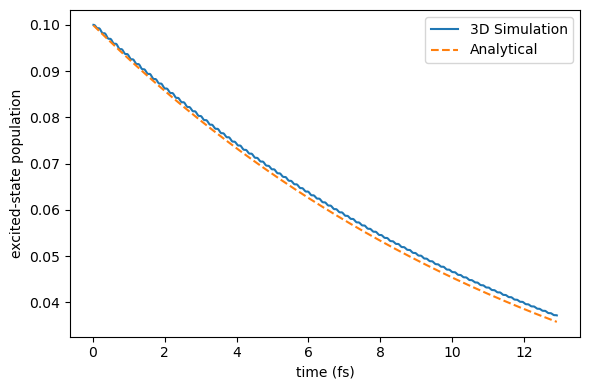

In [10]:
gamma_3d_au = (
    4.0 * mu12_au_3d**2 * omega_au_3d**3 / (3.0 * c_au**3)
)
decay_3d = np.exp(-gamma_3d_au * time_au_3d)
reference_3d = decay_3d / (
    decay_3d + (1.0 - pe_initial_3d) / pe_initial_3d
)

std_rel_3d = np.std(population_3d - reference_3d) / pe_initial_3d
max_rel_3d = np.max(np.abs(population_3d - reference_3d)) / pe_initial_3d
print(f"std_dev={std_rel_3d:.3e}, max_abs_diff={max_rel_3d:.3e}")

plt.figure(figsize=(6, 4))
plt.plot(time_au_3d * AU_TO_FS, population_3d, label="3D Simulation")
plt.plot(
    time_au_3d * AU_TO_FS,
    reference_3d,
    label="Analytical",
    linestyle="--",
)
plt.xlabel("time (fs)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Reduce the computational cost with cylindrical coordinates

The above 3D EM field with a $z$-oriented dipole is rotationally symmetric. Therefore, MaxwellLink can reproduce the above 3D calculation in cylindrical coordinates using the $m=0$ angular sector.

With cylindrical coordinates, this calculation only requires a 2D $(r,z)$ grid, so the computational cost can be significantly reduced.

In [ ]:
cylinder_radius = 0.5 * interior_size_3d
cell_size_cyl = mp.Vector3(
    cylinder_radius + pml_thickness_3d,
    0.0,
    interior_size_3d + 2.0 * pml_thickness_3d,
)

host_cyl, port_cyl = mxs.get_available_host_port()
hub_cyl = mxl.SocketHub(
    host=host_cyl, port=port_cyl, timeout=10.0, latency=1e-5
)

molecule_cyl = mxl.Molecule(
    hub=hub_cyl,
    # center here is (r=0, phi=0, z=0) in cylindrical coordinates
    center=mp.Vector3(0, 0, 0),
    # size here is (dr, dphi, dz) in cylindrical coordinates; dphi=0.0 is required for m=0
    size=mp.Vector3(molecule_size_3d, 0.0, molecule_size_3d),
    sigma=sigma_3d,
    # dimensions=mp.CYLINDRICAL is required for the cylindrical simulation
    dimensions=mp.CYLINDRICAL,
    resolution=resolution_3d,
    polarization_type="transverse",
)

sim_cyl = mxl.MeepSimulation(
    hub=hub_cyl,
    molecules=[molecule_cyl],
    cell_size=cell_size_cyl,
    boundary_layers=[mp.PML(pml_thickness_3d)],
    resolution=resolution_3d,
    length_units_nm=length_units_nm_3d,
    # dimensions=mp.CYLINDRICAL is required for the cylindrical simulation
    dimensions=mp.CYLINDRICAL,
    # this m=0 is needed for the cylindrical simulation 
    m=0
)

print(f"Cylindrical SocketHub listening on {host_cyl}:{port_cyl}")

[Init Molecule] Under socket mode, registered molecule with ID 0


 ######### MaxwellLink Units Helper #########
 MEEP uses its own units system, which is based on the speed of light in vacuum (c=1), 
 the permittivity of free space (epsilon_0=1), and the permeability of free space (mu_0=1). 
 To couple MEEP with molecular dynamics, we set [c] = [epsilon_0] = [mu_0] = [hbar] = 1. 
 By further defining the time unit or length unit, we can fix the units system of MEEP (mu).

 - Time [t]: 1 mu = 3.3356E+00 fs = 1.3790E+02 a.u.
 - Length [x]: 1 mu = 1.0000E+03 nm
 - EM wavelength of 1 mu, angular frequency omega = 2pi mu = 1.2404E+00 eV = 1.0004E+04 cm-1 = 4.5584E-02 a.u.
 - Note that sources and dielectrics defined in MEEP use rotational frequency (f=omega/2pi), 
 - so probabably we need covert 1 eV photon energy to rotational frequency f = 8.0619E-01 mu
 - Electric field [E]: 1 mu = 5.9755E+04 V/m = 1.1620E-07 a.u.

 Given the simulation resolution = 110,
 - FDTD dt = 4.5455E-03 mu (0.5/

Launching TLS driver via subprocess...
  /Users/taoli/miniforge3/envs/mxl/bin/mxl_driver --model tls --address 127.0.0.1 --port 52021 --param "omega=0.484, mu12=187.0, orientation=2, pe_initial=0.1"


-----------
Initializing structure...
time for choose_chunkdivision = 3.2e-05 s
Working in Cylindrical dimensions.
Computational cell is 0.145455 x 0 x 0.290909 with resolution 110
time for set_epsilon = 0.00029 s
-----------
[SocketHub][initialization] Time step in atomic units: 0.6268180813971947
[initialization] Assigned a molecular ID: 0
 CONNECTED: mol 0 <- 127.0.0.1:52023
init TLSModel with dt = 0.626818 a.u., molecule ID = 0
[initialization] Finished initialization for molecular ID: 0
run 0 finished at t = 3.868181818181818 (851 timesteps)
Received STOP, exiting
[SocketHub] DISCONNECTED: mol 0 from 127.0.0.1:52023
maximum 3D/cylindrical difference: 2.227e-03


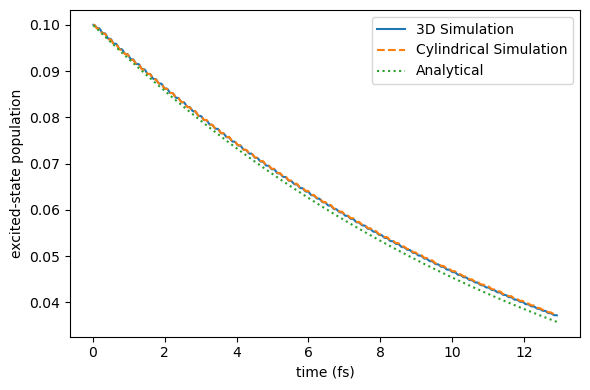

In [12]:
launch_tls_driver_3d(host_cyl, port_cyl)
sim_cyl.run(steps=steps_3d)

time_au_cyl = np.real(molecule_cyl.extra["time_au"])
population_cyl = np.real(molecule_cyl.extra["Pe"])

n_common = min(population_3d.size, population_cyl.size)
relative_difference = (
    np.max(np.abs(population_3d[:n_common] - population_cyl[:n_common]))
    / pe_initial_3d
)
print(f"maximum 3D/cylindrical difference: {relative_difference:.3e}")

plt.figure(figsize=(6, 4))
plt.plot(time_au_3d * AU_TO_FS, population_3d, label="3D Simulation")
plt.plot(
    time_au_cyl * AU_TO_FS,
    population_cyl,
    label="Cylindrical Simulation",
    linestyle="--",
)
plt.plot(
    time_au_3d * AU_TO_FS,
    reference_3d,
    label="Analytical",
    linestyle=":",
)
plt.xlabel("time (fs)")
plt.ylabel("excited-state population")
plt.legend()
plt.tight_layout()
plt.show()